# Title

This Jupyter notebook analyzes the FIFA 20 player dataset to identify top-performing players, evaluate team compositions, and analyze attribute distributions for player valuation. This exploratory data analysis helps inform in-game team building strategies and understanding player market value.
 
#  Summary Header
Title : FIFA 20 data analysis project
Author: Divyani Surma

# 2. Business Reason
The purpose of this analysis is to evaluate player statistics from FIFA 20 to enable informed decision-making for team composition and player acquisition.

.Identify Top Performers: Identify elite players based on overall rating (Overall) and potential (Potential).
.Value Optimization: Identify high-potential, low-cost players (undervalued talent).
.Attribute Analysis: Visualize distributions of skills (e.g., passing, shooting) to match specific team tactical requirements. 

# 3. Data Source

Dataset: FIFA 20 Player Data (fifa20.csv).
Contents: Contains 18,000+ players with over 100 attributes (e.g., Name, Age, Rating, Team,    Position, Salary)

# Task 1 Prepare a complete data analysis report on the given data

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [56]:
import pandas as pd

In [57]:
df = pd.read_csv("players_20.csv")
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel AndrÃ©s Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,AtlÃ©tico Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


In [58]:
df.tail()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
18273,245006,https://sofifa.com/player/245006/shuai-shao/20...,Shao Shuai,é‚µå¸…,22,1997-03-10,186,79,China PR,Beijing Renhe FC,...,43+2,42+2,42+2,42+2,43+2,45+2,46+2,46+2,46+2,45+2
18274,250995,https://sofifa.com/player/250995/mingjie-xiao/...,Xiao Mingjie,Mingjie Xiao,22,1997-01-01,177,66,China PR,Shanghai SIPG FC,...,44+2,43+2,43+2,43+2,44+2,46+2,47+2,47+2,47+2,46+2
18275,252332,https://sofifa.com/player/252332/wei-zhang/20/...,Zhang Wei,å¼ å¨,19,2000-05-16,186,75,China PR,Hebei China Fortune FC,...,47+2,49+2,49+2,49+2,47+2,47+2,49+2,49+2,49+2,47+2
18276,251110,https://sofifa.com/player/251110/haijian-wang/...,Wang Haijian,æ±ªæµ·å¥,18,2000-08-02,185,74,China PR,Shanghai Greenland Shenhua FC,...,48+2,48+2,48+2,48+2,48+2,48+2,49+2,49+2,49+2,48+2
18277,233449,https://sofifa.com/player/233449/ximing-pan/20...,Pan Ximing,æ½˜å–œæ˜Ž,26,1993-01-11,182,78,China PR,Hebei China Fortune FC,...,48+2,49+2,49+2,49+2,48+2,48+2,50+2,50+2,50+2,48+2


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB


In [60]:
df.describe

<bound method NDFrame.describe of        sofifa_id                                         player_url  \
0         158023  https://sofifa.com/player/158023/lionel-messi/...   
1          20801  https://sofifa.com/player/20801/c-ronaldo-dos-...   
2         190871  https://sofifa.com/player/190871/neymar-da-sil...   
3         200389  https://sofifa.com/player/200389/jan-oblak/20/...   
4         183277  https://sofifa.com/player/183277/eden-hazard/2...   
...          ...                                                ...   
18273     245006  https://sofifa.com/player/245006/shuai-shao/20...   
18274     250995  https://sofifa.com/player/250995/mingjie-xiao/...   
18275     252332  https://sofifa.com/player/252332/wei-zhang/20/...   
18276     251110  https://sofifa.com/player/251110/haijian-wang/...   
18277     233449  https://sofifa.com/player/233449/ximing-pan/20...   

              short_name                            long_name  age  \
0               L. Messi      Lionel AndrÃ©

In [61]:
df.dtypes

sofifa_id      int64
player_url    object
short_name    object
long_name     object
age            int64
               ...  
lb            object
lcb           object
cb            object
rcb           object
rb            object
Length: 104, dtype: object

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB


In [63]:
df.isnull().sum()

sofifa_id        0
player_url       0
short_name       0
long_name        0
age              0
              ... 
lb            2036
lcb           2036
cb            2036
rcb           2036
rb            2036
Length: 104, dtype: int64

# Task 2


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the dataset
# Assuming a CSV file 'players_20.csv' is in the directory
df = pd.read_csv('players_20.csv')

# Look at available columns to choose features
print(df.columns)


Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'nationality', 'club',
       ...
       'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb'],
      dtype='object', length=104)


In [83]:
# Select relevant features for clustering
features = ['shooting', 'passing', 'dribbling', 'defending', 'physic', 'pace', 
            'skill_ball_control', 'attacking_short_passing', 'attacking_finishing',
            'skill_dribbling', 'movement_acceleration', 'movement_sprint_speed',
            'power_stamina', 'defending_standing_tackle']

# Handle missing values
df = df.dropna(subset=features)

# Extract features for modeling
X = df[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [84]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])


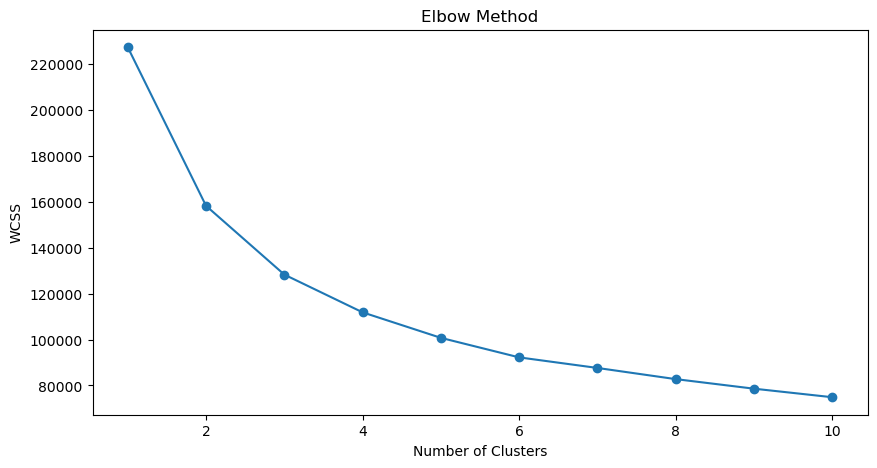

In [67]:
# Elbow method to find optimal K
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Based on elbow, choose K (e.g., 5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['Cluster'] = y_kmeans


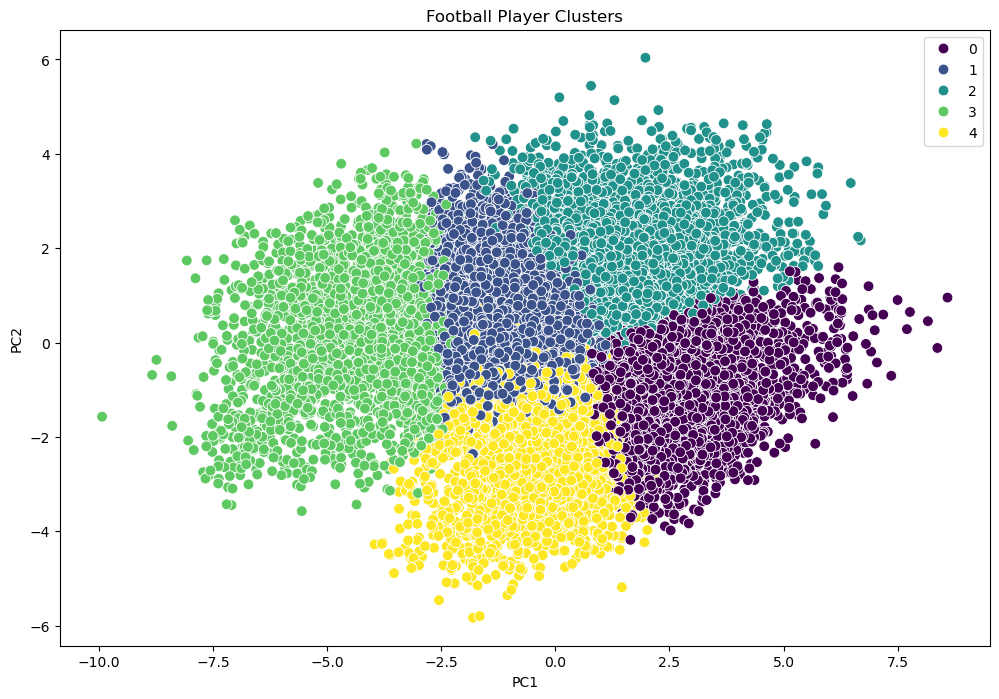

          shooting    passing  dribbling  defending     physic       pace  \
Cluster                                                                     
0        65.703704  63.072569  71.843421  36.607648  62.342066  78.398073   
1        43.188857  56.036662  60.034973  61.851182  67.428365  66.793536   
2        60.838448  68.232551  70.366727  65.008424  70.761432  68.405235   
3        32.222731  43.172773  45.101166  61.449209  67.416320  54.578684   
4        56.589046  51.588390  60.973762  31.365694  55.751394  66.853067   

         skill_ball_control  attacking_short_passing  attacking_finishing  \
Cluster                                                                     
0                 70.791328                66.495935            66.195122   
1                 61.117704                62.659913            38.417752   
2                 71.935018                72.433213            56.833333   
3                 48.492923                52.190258            27.354288  

In [68]:
# Visualize clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=y_kmeans, palette='viridis', s=60)
plt.title('Football Player Clusters')
plt.show()

# Analyze cluster averages to understand archetypes
cluster_profiles = df.groupby('Cluster')[features].mean()
print(cluster_profiles)



K-Means model created 5 player clusters (0,1,2,3,4) using PCA visualization. Each color represents a different type of football player.

Interpretation of Each Cluster

Cluster 0 (Purple) – Attacking Players ⚡

* Located right side, lower PC2
* Likely players with good pace, dribbling, shooting
* Wingers / Strikers / CAMs

Meaning: Offensive players with strong attacking skills.



Cluster 1 (Blue) – Balanced Midfielders 🎯

* Center area of graph
* Mixed attributes: passing, stamina, control

Meaning: Versatile midfield players who support attack and defense.


Cluster 2 (Teal) – Elite / High Performance Players ⭐

* Upper-right side with higher PC2 values
* Likely high overall rating and strong all-round stats

Meaning: Top-level players with strong performance.


Cluster 3 (Green) – Defensive / Average Players 🛡️

* Left side of graph
* Lower attacking stats, more physical/defensive

Meaning: Defenders, CDMs, average-rated players.


Cluster 4 (Yellow) – Young / Low Rated Players 🌱

* Small bottom-center cluster
* Lower stats and experience

Meaning: Young talents, substitutes, developing players.

# Task 3

In [69]:
df.columns

Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'nationality', 'club',
       ...
       'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb', 'Cluster'],
      dtype='object', length=105)

In [70]:
df['nationality'].value_counts(10)

nationality
England        0.092168
Germany        0.064955
Spain          0.056766
France         0.054242
Argentina      0.049009
                 ...   
Malawi         0.000062
Gibraltar      0.000062
Macau          0.000062
South Sudan    0.000062
Indonesia      0.000062
Name: proportion, Length: 161, dtype: float64

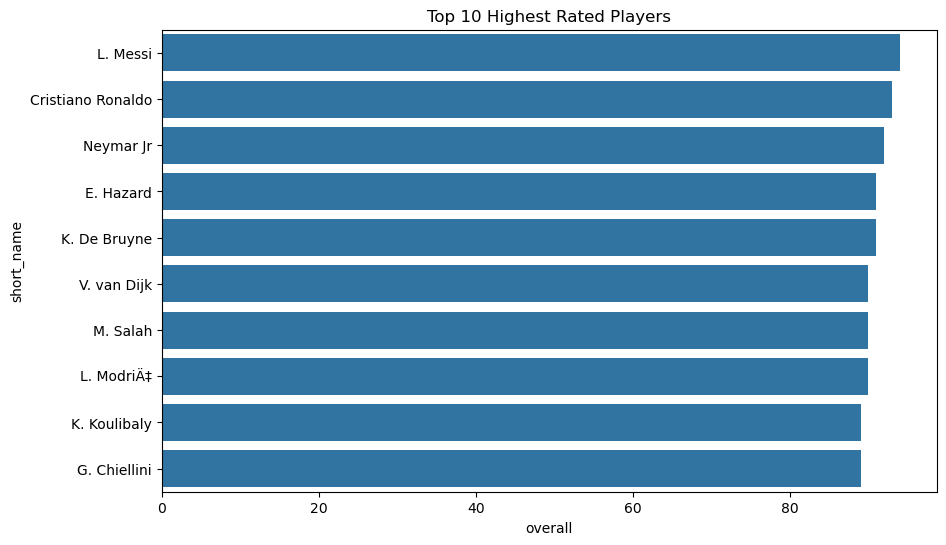

In [71]:
top_players = df.sort_values(by='overall', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='overall', y='short_name', data=top_players)
plt.title("Top 10 Highest Rated Players")
plt.show()

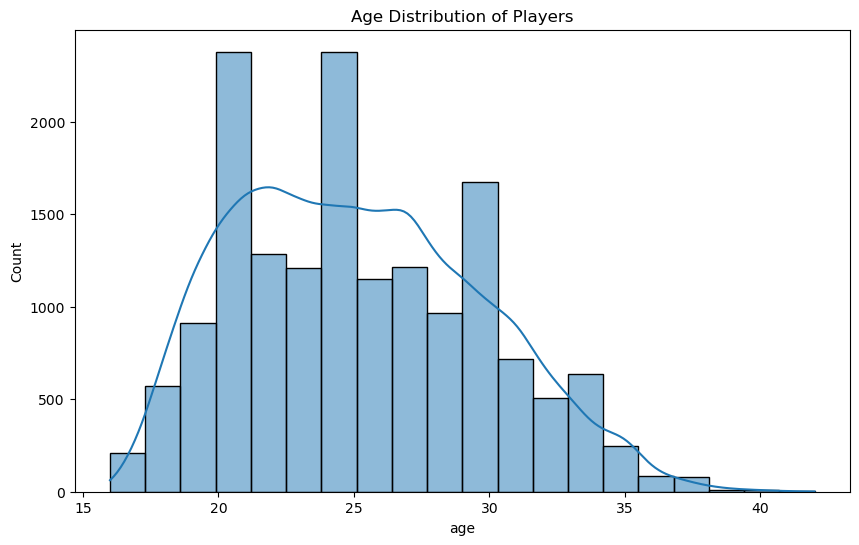

In [72]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution of Players")
plt.show()

The histogram shows that most FIFA20 players are between 20 and 30 years old, with the highest concentration around 24-28 years. Very few players are younger than 18 or older than 35. This indicates that the dataset mainly consists of players in their peak performance age range.

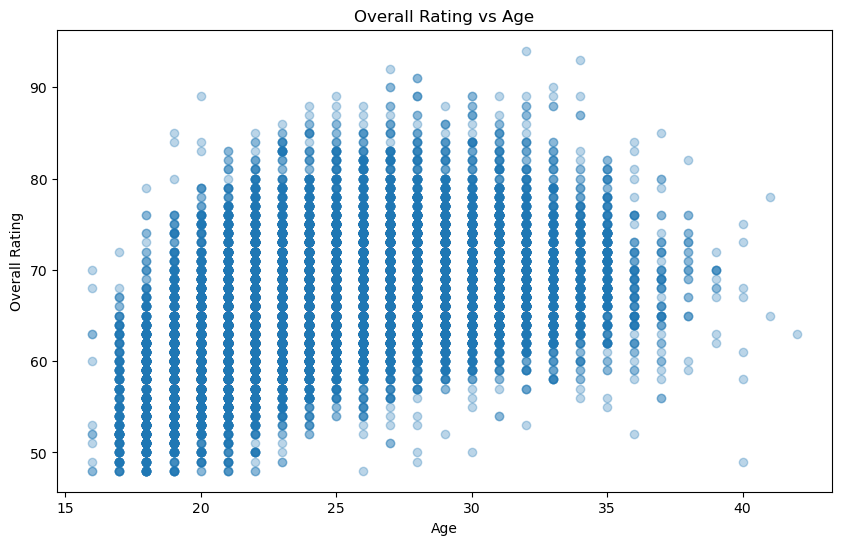

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df['age'], df['overall'], alpha=0.3)

plt.xlabel("Age")
plt.ylabel("Overall Rating")
plt.title("Overall Rating vs Age")

plt.show()

The relationship between age and overall rating shows that player ratings generally increase with age and experience, reaching their peak around the mid-20s to early-30s. After this stage, ratings may stabilize or slightly decline. Younger players usually have lower overall ratings but higher growth potential, while older players often have more experience and consistent performance.

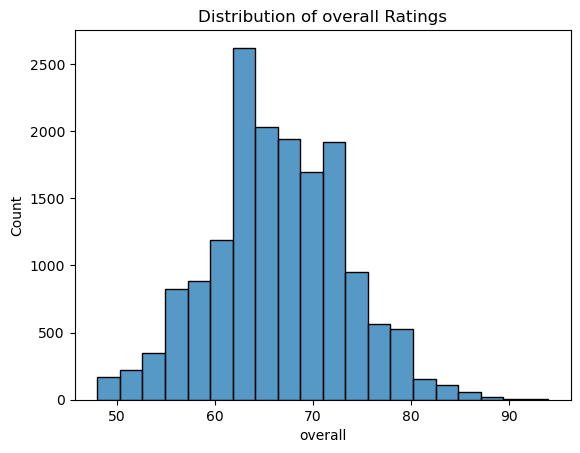

In [74]:
sns.histplot(df['overall'], bins=20)
plt.title("Distribution of overall Ratings")
plt.show()

The relationship between age and overall rating shows that player ratings generally increase with age and experience, reaching their peak around the mid-20s to early-30s. After this stage, ratings may stabilize or slightly decline. Younger players usually have lower overall ratings but higher growth potential, while older players often have more experience and consistent performance.

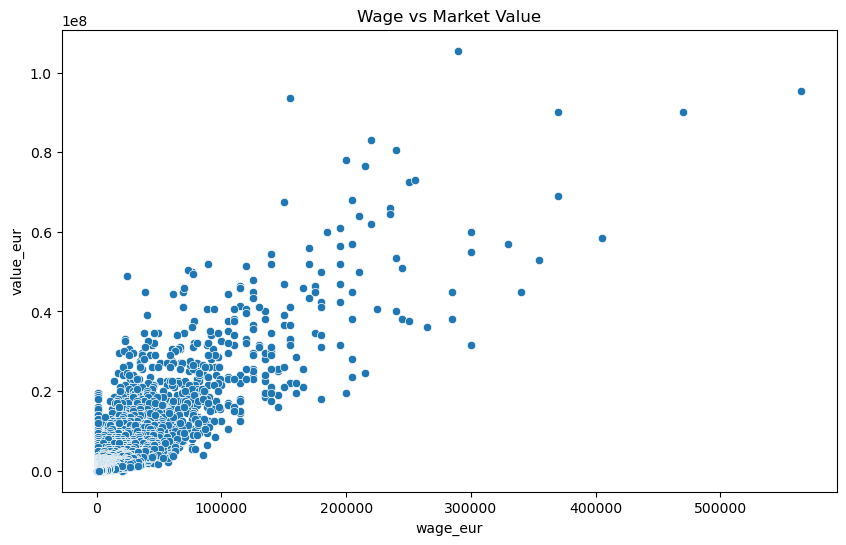

In [75]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='wage_eur', y='value_eur', data=df)
plt.title("Wage vs Market Value")
plt.show()

The relationship between age and overall rating shows that player ratings generally increase with age and experience, reaching their peak around the mid-20s to early-30s. After this stage, ratings may stabilize or slightly decline. Younger players usually have lower overall ratings but higher growth potential, while older players often have more experience and consistent performance.

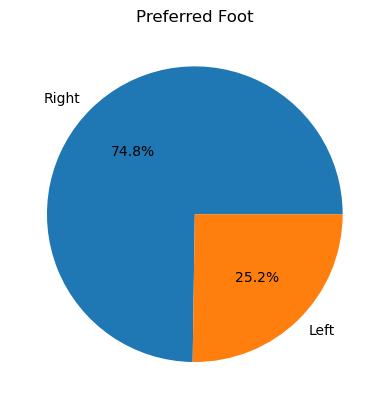

In [76]:
df['preferred_foot'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Preferred Foot")
plt.ylabel("")
plt.show()

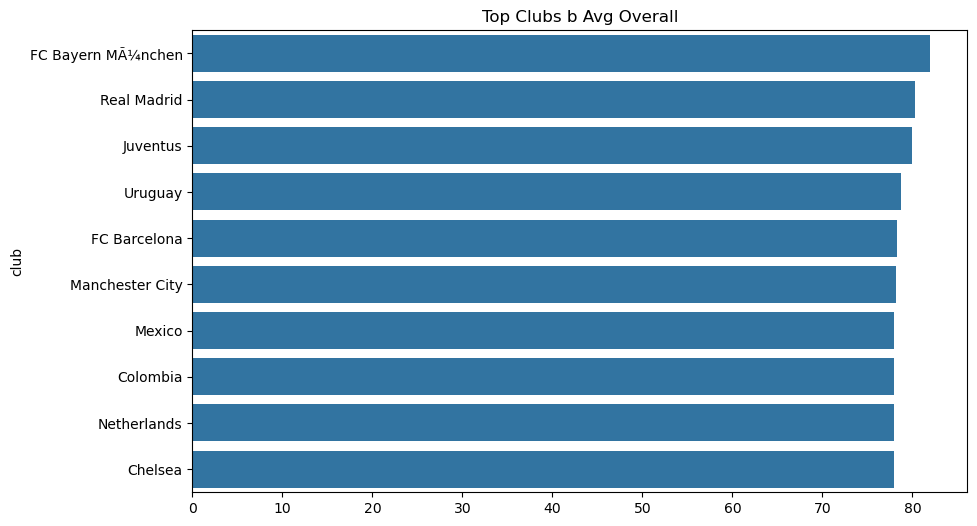

In [77]:
club_rating = df.groupby('club')['overall'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=club_rating.values, y=club_rating.index)
plt.title("Top Clubs b Avg Overall")
plt.show()

## Correlation Heatmap

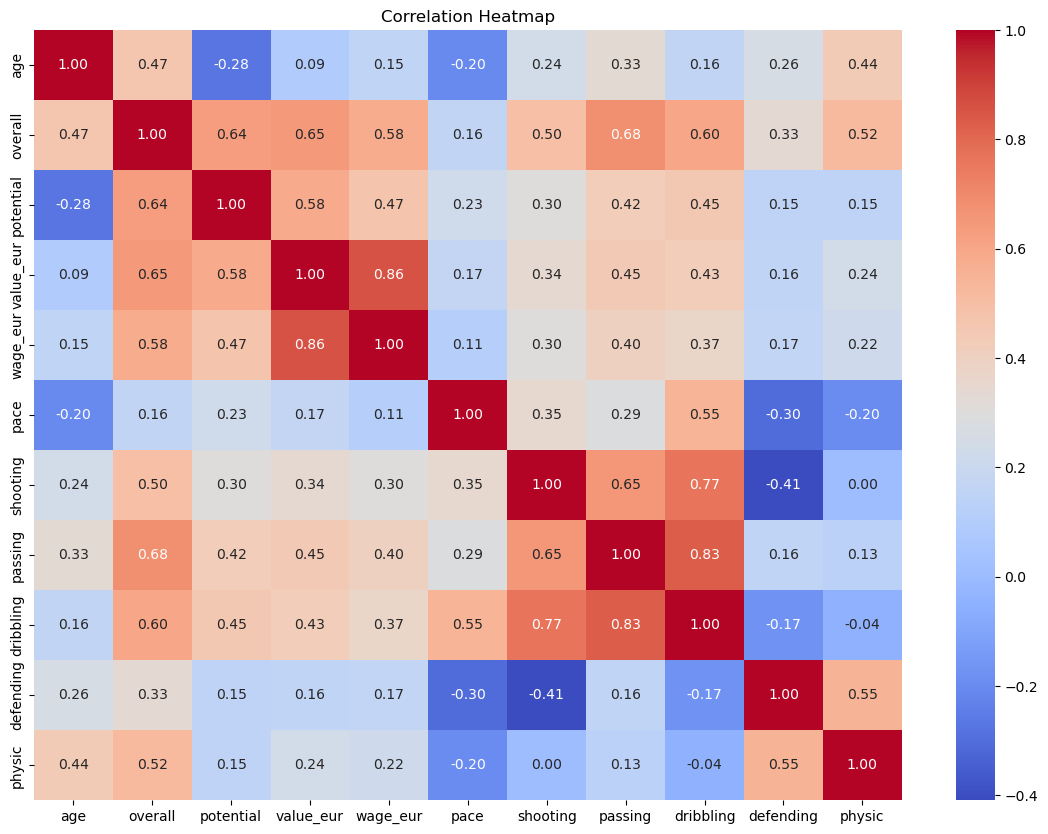

In [78]:
plt.figure(figsize=(14,10))

cols = ['age','overall','potential','value_eur','wage_eur',
        'pace','shooting','passing','dribbling','defending','physic']

sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

## Interpretation

A correlation heatmap shows the relationship between numeric variables from -1 to +1.

* +1 (Dark Red) = Strong positive relationship
* -1 (Dark Blue) = Strong negative relationship
* 0 (Light color) = No strong relationship

Key Interpretations for FIFA Dataset

1. Overall Rating and Value (value_eur) → Strong Positive Correlation
    Players with higher overall ratings usually have higher market value.
2. Overall Rating and Wage (wage_eur) → Positive Correlation
    Better players tend to earn higher wages.
3. Potential and Overall → Positive Correlation
    Players with high potential usually already have good ratings.
4. Age and Potential → Negative Correlation
    Younger players generally have higher future potential than older players.
5. Skill Attributes (Passing, Dribbling, Shooting) → Positive Correlation
    Technical skills often improve together in quality players.
6. Goalkeeping Stats (GK Reflexes, GK Diving, GK Handling) → Strong Positive Correlation
    Goalkeeper attributes are highly related to each other.
7. Outfield Skills vs Goalkeeping Skills → Negative / Weak Correlation
    Normal players usually do not have strong goalkeeper stats.

Conclusion

The heatmap indicates that player value and wages depend strongly on overall performance, while younger players tend to have greater potential. Similar skill sets are positively related, showing balanced player development.

# Type of offensive players tends to get paid the most

In [79]:
import pandas as pd
df.columns  

Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'nationality', 'club',
       ...
       'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb', 'Cluster'],
      dtype='object', length=105)

In [80]:
# filter relevant position
offensive = df[df['player_positions'].isin(['ST','RW','LW'])]

# Average wage/salary
salary_comparison = offensive.groupby('player_positions') ['wage_eur'].mean()

print(salary_comparison)

player_positions
LW     9681.818182
RW     6208.791209
ST    10256.495301
Name: wage_eur, dtype: float64


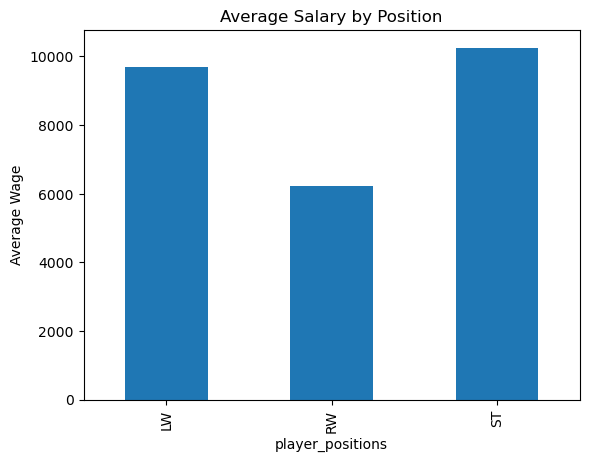

In [81]:
salary_comparison.plot(kind='bar')
plt.title("Average Salary by Position")
plt.ylabel("Average Wage")
plt.show()

This analysis compares the average wages of offensive football players such as:

* ST = Striker
* RW = Right Winger
* LW = Left Winger

using the wage_eur column.

Key Interpretation

1. Strikers usually earn the highest wages
    Strikers are responsible for scoring goals, so clubs often pay them more.
2. Wingers (RW / LW) also receive high salaries
    Wingers create chances, provide assists, and score goals, making them valuable attacking players.
3. Attacking positions are generally paid more than defensive positions
    Clubs invest more in players who directly influence goals and match outcomes.
4. Famous star attackers increase the average wage
    High-profile players in these positions can raise the mean salary significantly.

Conclusion

The graph shows that offensive players, especially strikers and wingers, tend to receive higher wages because of their impact on scoring and winning matches.